# SVM Classifier on sklearn Digits Dataset

This notebook trains and evaluates Support Vector Machine (SVM) models on `sklearn.datasets.load_digits`.

Goals:
- Compare model accuracy with `linear` and `rbf` kernels.
- Use exactly 80% of the dataset for training.
- Tune `C` (regularization) and `gamma` to find the highest accuracy.


## 1) Setup

Import dependencies and define a fixed random seed for reproducibility.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC

SEED = 42


## 2) Load and inspect digits data

The digits dataset has 1797 samples and each sample has 64 features (8x8 grayscale image flattened).


In [29]:
digits = load_digits()
X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", digits.target_names)


Dataset shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [30]:
sample_df = pd.DataFrame(X[:5], columns=[f"pixel_{i}" for i in range(X.shape[1])])
sample_df["target"] = y[:5]
sample_df.head()


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 3) Train-test split (80% train, 20% test)

Use stratification to preserve class distribution in train and test sets.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train ratio:", round(len(X_train) / len(X), 2))


Train size: 1437
Test size: 360
Train ratio: 0.8


## 4) Baseline kernel comparison (`linear` vs `rbf`)

Train separate SVM models with default settings for each kernel and compare test accuracy.


In [32]:
kernel_scores = []
baseline_models = {}

for kernel_name in ["linear", "rbf"]:
    model = SVC(kernel=kernel_name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    baseline_models[kernel_name] = model
    kernel_scores.append({"kernel": kernel_name, "test_accuracy": acc})

kernel_results_df = pd.DataFrame(kernel_scores).sort_values("test_accuracy", ascending=False)
kernel_results_df


,kernel,test_accuracy
1,rbf,0.991667
0,linear,0.977778


## 5) Hyperparameter tuning (`C` and `gamma`)

Use `GridSearchCV` on the training set to tune parameters.

- For `linear`, tune `C`.
- For `rbf`, tune both `C` and `gamma`.


In [33]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": [0.0001, 0.001, 0.01, 0.1, 1]
    }
]

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))


Best parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9896


## 6) Final evaluation on test set

Evaluate the best tuned model on the held-out test split.


In [34]:
best_model = grid_search.best_estimator_
best_test_accuracy = best_model.score(X_test, y_test)

print("Best model:", best_model)
print("Test accuracy (tuned):", round(best_test_accuracy, 4))


Best model: SVC(C=10, gamma=0.001)
Test accuracy (tuned): 0.9917


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      0.97      0.97        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



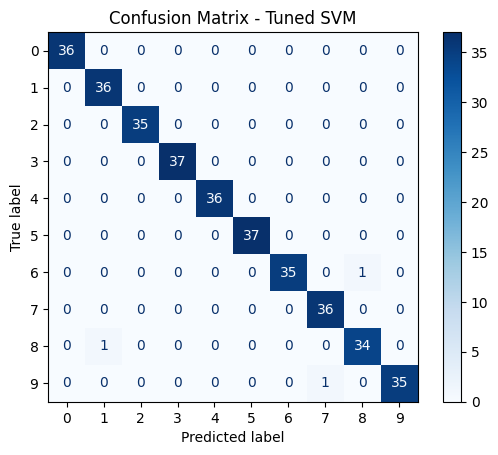

In [35]:
y_test_pred = best_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()


## 7) Summary table

Compare baseline kernel scores with the tuned model test score.


In [36]:
summary_df = kernel_results_df.copy()
summary_df.loc[len(summary_df)] = {
    "kernel": f"tuned ({grid_search.best_params_['kernel']})",
    "test_accuracy": best_test_accuracy
}

summary_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)


,kernel,test_accuracy
0,rbf,0.991667
1,tuned (rbf),0.991667
2,linear,0.977778
